## 8. Model comparison


# Assignment 3 — Phase 2 & 3 (Rohan Chaudhary)


### Models

- **Model 1:** VGG-16-BN global + 2-layer GRU
- **Model 2:** ResNet-50 spatial + Bahdanau attention LSTM + feature dropout

## 0. Imports and configuration


In [ ]:
import re
import json
import pickle
import random
import math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import VGG16_BN_Weights, vgg16_bn

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
#  Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
USE_PIN_MEMORY = DEVICE.type == "cuda"  

if DEVICE.type == "mps":
  import os
  os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

#   Paths 
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR
IMAGE_DIR = DATA_DIR / "val"
ANNOTATIONS_PATH = DATA_DIR / "annotations" / "val.json"
ARTEFACTS_DIR = DATA_DIR / "artefacts"
RESULTS_DIR = DATA_DIR / "results"
CHECKPOINTS_DIR = DATA_DIR / "checkpoints"
RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)


# . Hyperparameters (shared data) 
MIN_WORD_FREQ = 5
MAX_CAPTION_LEN = 50
BATCH_SIZE = 32
NUM_WORKERS = 0  

# Decoding & training 
BEAM_WIDTH = 5
MAX_DECODE_LEN = 50


QUICK_TEST = False

# BLEU:
MAX_BLEU_IMAGES = None 
SKIP_MODEL1_TRAINING = True 
FORCE_RETRAIN = False       
FORCE_RETRAIN_MODEL2 = False 
SKIP_TRAIN_IF_CKPT = not (FORCE_RETRAIN or FORCE_RETRAIN_MODEL2)

# Stale checkpoint cleanup
for _ck in [CHECKPOINTS_DIR / "model1_best.pt"]:
    if FORCE_RETRAIN and _ck.exists():
        _ck.unlink(); print(f"Removed stale checkpoint: {_ck.name}")
if FORCE_RETRAIN_MODEL2 and (CHECKPOINTS_DIR / "model2_best.pt").exists():
    (CHECKPOINTS_DIR / "model2_best.pt").unlink()
    print("Removed stale checkpoint: model2_best.pt")
RUN_GREEDY_BLEU = False  

def verify_project_layout() -> None:
    errors = []
    if not IMAGE_DIR.is_dir() or not any(IMAGE_DIR.glob("*.jpg")):
        errors.append(f"Image folder missing or empty: {IMAGE_DIR}")
    if not ANNOTATIONS_PATH.is_file():
        errors.append(f"Annotations missing: {ANNOTATIONS_PATH}")
    for name in ("vocab.pkl", "splits.json", "id_to_tokens.json", "metadata.json"):
        if not (ARTEFACTS_DIR / name).is_file():
            errors.append(f"Run Phase 1 first — missing artefacts/{name}")
    if errors:
        raise FileNotFoundError("\n".join(errors))
    print("Preflight OK: data + Phase 1 artefacts found.")

try:
    import nltk
    nltk.download("punkt", quiet=True)
except Exception:
    pass

print(f"Project: {PROJECT_DIR}")
print(f"Device:  {DEVICE} ({'Apple MPS' if DEVICE.type == 'mps' else DEVICE.type})")
print(f"Results: {RESULTS_DIR}")
if QUICK_TEST:
    print("QUICK_TEST=True → 1 epoch per model only")












Project: /Users/rohanchaudhary/projects/DL_AT3
Device:  mps (Apple MPS)
Results: /Users/rohanchaudhary/projects/DL_AT3/results


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


## 1. Vocabulary (required before loading `vocab.pkl`)


In [2]:
class Vocabulary:
    PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN = "<PAD>", "<START>", "<END>", "<UNK>"
    PAD_IDX, START_IDX, END_IDX, UNK_IDX = 0, 1, 2, 3

    def __init__(self, min_freq: int = 5) -> None:
        self.min_freq = min_freq
        self.word2idx: Dict[str, int] = {}
        self.idx2word: Dict[int, str] = {}
        for idx, tok in enumerate([self.PAD_TOKEN, self.START_TOKEN, self.END_TOKEN, self.UNK_TOKEN]):
            self.word2idx[tok] = idx
            self.idx2word[idx] = tok

    @classmethod
    def from_artefacts(cls, artefacts_dir: Path) -> "Vocabulary":
        """Load Phase 1 portable vocab dict (stoi/itos + special indices)."""
        with open(artefacts_dir / "metadata.json") as f:
            meta = json.load(f)
        with open(artefacts_dir / "vocab.pkl", "rb") as f:
            data = pickle.load(f)
        if not isinstance(data, dict):
            return data
        v = cls(min_freq=data.get("freq_threshold", MIN_WORD_FREQ))
        v.word2idx = dict(data["stoi"])
        itos = data["itos"]
        if isinstance(itos, list):
            v.idx2word = {i: w for i, w in enumerate(itos)}
        else:
            v.idx2word = {int(k): w for k, w in dict(itos).items()}
        specials = meta.get("special_tokens", {})
        v.PAD_IDX = int(data.get("pad_idx", specials.get("pad_idx", 0)))
        v.START_IDX = int(data.get("sos_idx", specials.get("sos_idx", 1)))
        v.END_IDX = int(data.get("eos_idx", specials.get("eos_idx", 2)))
        v.UNK_IDX = int(data.get("unk_idx", specials.get("unk_idx", 3)))
        return v

    def encode(self, tokens: List[str]) -> List[int]:
        return [self.START_IDX] + [self.word2idx.get(t, self.UNK_IDX) for t in tokens] + [self.END_IDX]

    def decode(self, indices: List[int], skip_special: bool = True) -> str:
        words = []
        for idx in indices:
            if idx == self.END_IDX:
                break
            if skip_special and idx in (self.PAD_IDX, self.START_IDX):
                continue
            words.append(self.idx2word.get(idx, self.UNK_TOKEN))
        return " ".join(words)

    def __len__(self) -> int:
        return len(self.word2idx)

    def __contains__(self, word: str) -> bool:
        return word in self.word2idx


PAD_IDX = Vocabulary.PAD_IDX
START_IDX = Vocabulary.START_IDX
END_IDX = Vocabulary.END_IDX



## 2. Load annotations and Phase 1 artefacts


In [ ]:
_PUNCT_RE = re.compile(r"[^\w\s]")
_SPACE_RE = re.compile(r"\s+")

def clean_caption(text: str) -> str:
    text = text.lower()
    text = _PUNCT_RE.sub(" ", text)
    text = _SPACE_RE.sub(" ", text)
    return text.strip()

def tokenise(text: str) -> List[str]:
    return text.split()

verify_project_layout()

# Phase 1 metadata 
with open(ARTEFACTS_DIR / "metadata.json") as f:
    phase1_meta = json.load(f)
MAX_CAPTION_LEN = int(phase1_meta.get("max_caption_len", MAX_CAPTION_LEN))

with open(ANNOTATIONS_PATH) as f:
    raw = json.load(f)

id_to_filename: Dict[int, str] = {int(img["id"]): img["file_name"] for img in raw["images"]}

# Prefer Phase 1 tokenised captions (exact match to vocab)
id_to_tokens_path = ARTEFACTS_DIR / "id_to_tokens.json"
if id_to_tokens_path.exists():
    with open(id_to_tokens_path) as f:
        id_to_tokens_raw = json.load(f)
    id_to_captions: Dict[int, List[List[str]]] = {}
    for iid, caps in id_to_tokens_raw.items():
        filtered = [toks[:MAX_CAPTION_LEN] for toks in caps if 'quality issues' not in ' '.join(toks)]
        id_to_captions[int(iid)] = filtered if filtered else [toks[:MAX_CAPTION_LEN] for toks in caps]
    n_empty = sum(1 for v in id_to_captions.values() if not v)
    print(f"Filtered quality-issue captions; images with no alt caps (fallback): {n_empty}")
else:
    id_to_captions = {}
    for ann in raw["annotations"]:
        iid = int(ann["image_id"])
        tokens = tokenise(clean_caption(ann["caption"]))[:MAX_CAPTION_LEN]
        id_to_captions.setdefault(iid, []).append(tokens)

with open(ARTEFACTS_DIR / "splits.json") as f:
    splits = json.load(f)

train_ids = [int(x) for x in splits["train"]]
val_ids = [int(x) for x in splits["val"]]
test_ids = [int(x) for x in splits["test"]]

vocab = Vocabulary.from_artefacts(ARTEFACTS_DIR)
PAD_IDX = vocab.PAD_IDX
START_IDX = vocab.START_IDX
END_IDX = vocab.END_IDX

print(f"Phase 1: {phase1_meta.get('phase', 'artefacts')} | vocab_size={len(vocab)}")
print(f"Images in annotations: {len(id_to_filename)}")
print(f"Train / val / test:    {len(train_ids)} / {len(val_ids)} / {len(test_ids)}")
print(f"Special tokens: pad={PAD_IDX} start={START_IDX} end={END_IDX}")





Preflight OK: data + Phase 1 artefacts found.
Filtered quality-issue captions; images with no alt caps (fallback): 0
Phase 1: Phase 1 - Data Preparation | vocab_size=3274
Images in annotations: 7750
Train / val / test:    5425 / 1162 / 1163
Special tokens: pad=0 start=1 end=2


## 3. Dataset, transforms, and DataLoaders


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class VizWizDataset(Dataset):
    def __init__(self, image_ids, id_to_filename, id_to_captions_clean, vocab, image_dir, transform, training=True):
        self.vocab = vocab
        self.image_dir = image_dir
        self.transform = transform
        self.training = training
        self.samples = []
        missing = 0
        for iid in image_ids:
            fname = id_to_filename[iid]
            if not (image_dir / fname).exists():
                missing += 1
                continue
            self.samples.append((iid, fname, id_to_captions_clean[iid]))
        if missing:
            print(f"[Warning] {missing} images missing on disk.")
        print(f"Dataset ({'train' if training else 'eval'}): {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        iid, fname, token_lists = self.samples[idx]
        image = Image.open(self.image_dir / fname).convert("RGB")
        image = self.transform(image)
        if self.training:
            tokens = random.choice(token_lists)
            encoded = self.vocab.encode(tokens)
            caption = torch.tensor(encoded, dtype=torch.long)
            return image, caption, torch.tensor(len(encoded), dtype=torch.long)
        all_encoded = [torch.tensor(self.vocab.encode(toks), dtype=torch.long) for toks in token_lists]
        lengths = torch.tensor([len(e) for e in all_encoded], dtype=torch.long)
        return image, all_encoded, lengths


def collate_train(batch):
    images, captions, lengths = zip(*batch)
    images = torch.stack(images, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    lengths = torch.stack(lengths, dim=0)
    return images, captions, lengths


def collate_eval(batch):
    images, all_captions, all_lengths = zip(*batch)
    images = torch.stack(images, dim=0)
    # Variable number of refs per image after quality-caption filtering
    return images, list(all_captions), list(all_lengths)


train_dataset = VizWizDataset(train_ids, id_to_filename, id_to_captions, vocab, IMAGE_DIR, train_transform, True)
val_dataset = VizWizDataset(val_ids, id_to_filename, id_to_captions, vocab, IMAGE_DIR, eval_transform, False)
test_dataset = VizWizDataset(test_ids, id_to_filename, id_to_captions, vocab, IMAGE_DIR, eval_transform, False)

# Training-mode val/test sets for teacher-forcing loss (one random caption per image)
val_loss_dataset = VizWizDataset(val_ids, id_to_filename, id_to_captions, vocab, IMAGE_DIR, eval_transform, True)
test_loss_dataset = VizWizDataset(test_ids, id_to_filename, id_to_captions, vocab, IMAGE_DIR, eval_transform, True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=USE_PIN_MEMORY, collate_fn=collate_train, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY,
                        collate_fn=collate_eval)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         collate_fn=collate_eval)
val_loss_loader = DataLoader(val_loss_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY,
                             collate_fn=collate_train)
test_loss_loader = DataLoader(test_loss_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                              collate_fn=collate_train)

assert len(train_dataset) > 5000, "Train set too small — check splits / paths"
BATCH_SIZE_M2 = min(20, BATCH_SIZE)  # ResNet-50 + attention on MPS  # EfficientNet-B3 needs smaller batches on MPS
train_loader_m2 = DataLoader(train_dataset, batch_size=BATCH_SIZE_M2, shuffle=True, num_workers=NUM_WORKERS,
                               pin_memory=USE_PIN_MEMORY, collate_fn=collate_train, drop_last=True)
val_loss_loader_m2 = DataLoader(val_loss_dataset, batch_size=BATCH_SIZE_M2, shuffle=False, num_workers=NUM_WORKERS,
                                pin_memory=USE_PIN_MEMORY, collate_fn=collate_train)
test_loss_loader_m2 = DataLoader(test_loss_dataset, batch_size=BATCH_SIZE_M2, shuffle=False, num_workers=NUM_WORKERS,
                                 pin_memory=USE_PIN_MEMORY, collate_fn=collate_train)
print(f"Train batches: M1={len(train_loader)} M2={len(train_loader_m2)} | Val BLEU: {len(val_loader)}")







Dataset (train): 5425 images
Dataset (eval): 1162 images
Dataset (eval): 1163 images
Dataset (train): 1162 images
Dataset (train): 1163 images
Train batches: M1=169 M2=271 | Val BLEU: 37


## 4. Visualization helpers (inline matplotlib)

Charts render **inside this notebook** when you run each cell (`plt.show()`). Loss CSVs are still saved under `results/` for tables; figures are not written as separate `.png` files.


In [5]:
FIGSIZE = (10, 5)

# Inline plots only (saved in notebook outputs when you Run All — no separate image files).


def _history_to_arrays(history):
    """Accept list[dict] or pandas DataFrame with epoch, train_loss, val_loss, test_loss."""
    if isinstance(history, pd.DataFrame):
        df = history
    else:
        df = pd.DataFrame(history)
    epochs = df["epoch"].values
    test_l = df["test_loss"].values if "test_loss" in df.columns else None
    return epochs, df["train_loss"].values, df["val_loss"].values, test_l


def plot_loss_curves(history, title: str):
    """Line plot of train / val / test loss vs epoch (inline)."""
    epochs, train_l, val_l, test_l = _history_to_arrays(history)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(epochs, train_l, marker="o", label="Train")
    ax.plot(epochs, val_l, marker="o", label="Validation")
    if test_l is not None:
        ax.plot(epochs, test_l, marker="o", label="Test")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (cross-entropy)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def plot_losses_from_csv(csv_path, title: str):
    """Reload loss history from CSV and plot inline."""
    df = pd.read_csv(csv_path)
    return plot_loss_curves(df, title)


def plot_bleu_scores(bleu_dict: dict, title: str):
    """Bar chart for BLEU-1,2,3,4 (inline)."""
    labels, values = [], []
    for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
        if k in bleu_dict:
            labels.append(k)
            values.append(bleu_dict[k])
    if not labels:
        for i in range(1, 5):
            key = f"bleu_{i}"
            if key in bleu_dict:
                labels.append(f"BLEU-{i}")
                values.append(bleu_dict[key])
    fig, ax = plt.subplots(figsize=FIGSIZE)
    x = np.arange(len(labels))
    ax.bar(x, values, color="steelblue", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("BLEU score")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def plot_model_comparison(model1_bleu: dict, model2_bleu: dict, split_label: str = "validation"):
    """Grouped bar chart: Model 1 vs Model 2 for BLEU-1..4 (inline)."""
    metrics = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
    m1 = [model1_bleu.get(m, model1_bleu.get(f"bleu_{i}", 0)) for i, m in enumerate(metrics, 1)]
    m2 = [model2_bleu.get(m, model2_bleu.get(f"bleu_{i}", 0)) for i, m in enumerate(metrics, 1)]
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.bar(x - width / 2, m1, width, label="Model 1 (VGG16+GRU)")
    ax.bar(x + width / 2, m2, width, label="Model 2 (EfficientNet+Transformer)")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("BLEU score")
    ax.set_ylim(0, 1)
    ax.set_title(f"Model comparison — {split_label} BLEU")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def plot_val_loss_comparison(csv_m1: Path, csv_m2: Path):
    """Overlay validation loss curves for both models (inline)."""
    df1 = pd.read_csv(csv_m1)
    df2 = pd.read_csv(csv_m2)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(df1["epoch"], df1["val_loss"], marker="o", label="Model 1 val loss")
    ax.plot(df2["epoch"], df2["val_loss"], marker="o", label="Model 2 val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss")
    ax.set_title("Validation loss comparison")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def show_prediction_samples(model, loader, vocab, n: int = 3, max_len: int = 50):
    """Display image + generated caption + one reference (inline matplotlib subplots)."""
    model.eval()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    images, all_caps, _ = next(iter(loader))
    n = min(n, images.size(0))
    fig, axes = plt.subplots(n, 1, figsize=(8, 4 * n))
    if n == 1:
        axes = [axes]
    with torch.no_grad():
        for i in range(n):
            img_t = images[i : i + 1].to(DEVICE)
            pred_ids = decode_caption(model, img_t, beam_width=BEAM_WIDTH, max_len=max_len)
            pred_text = vocab.decode(pred_ids)
            ref_text = vocab.decode(all_caps[i][0].tolist())
            img_show = images[i].cpu() * std + mean
            img_show = img_show.permute(1, 2, 0).numpy()
            img_show = np.clip(img_show, 0, 1)
            axes[i].imshow(img_show)
            axes[i].axis("off")
            axes[i].set_title(f"Pred: {pred_text}\nRef:  {ref_text}", fontsize=9)
    plt.tight_layout()
    plt.show()

print("Visualization helpers defined (inline matplotlib only).")






Visualization helpers defined (inline matplotlib only).


## 5. Shared training and evaluation utilities


In [6]:


def masked_caption_loss(outputs: torch.Tensor, targets: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    """Cross-entropy only on valid timesteps (attention decoder batches)."""
    b, t_out, v = outputs.shape
    t_tgt = targets.size(1)
    t = min(t_out, t_tgt)
    if t == 0:
        return outputs.sum() * 0.0
    out = outputs[:, :t, :].reshape(-1, v)
    tgt = targets[:, :t].reshape(-1)
    if lengths is not None:
        mask = torch.zeros(b, t, dtype=torch.bool, device=targets.device)
        for i, L in enumerate(lengths.tolist()):
            n = max(0, int(L) - 1)
            mask[i, : min(n, t)] = True
        out = outputs[:, :t, :][mask]
        tgt = targets[:, :t][mask]
    return criterion(out, tgt)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
bleu_smooth = SmoothingFunction().method1

try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm



def set_encoder_trainable(model: nn.Module, trainable: bool) -> None:
    if hasattr(model, "encoder") and hasattr(model.encoder, "set_fine_tune"):
        model.encoder.set_fine_tune(trainable)
        n = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
        print(f"  Encoder {'unfrozen' if trainable else 'frozen'} ({n:,} trainable params)")
        return
    if hasattr(model, "encoder"):
        for p in model.encoder.parameters():
            p.requires_grad = trainable

def _strip_generated(indices: List[int]) -> List[int]:
    out = []
    for idx in indices:
        if idx == END_IDX:
            break
        if idx not in (PAD_IDX, START_IDX):
            out.append(idx)
    return out


@torch.no_grad()
def greedy_decode(model, images, max_len: int = MAX_DECODE_LEN) -> List[int]:
    if hasattr(model, "greedy_decode"):
        return model.greedy_decode(images, max_len)
    raise NotImplementedError("Model must implement greedy_decode")


@torch.no_grad()
def beam_decode(model, images, beam_width: int = BEAM_WIDTH, max_len: int = MAX_DECODE_LEN) -> List[int]:
    if beam_width <= 1:
        return greedy_decode(model, images, max_len)
    if hasattr(model, "beam_search"):
        return model.beam_search(images, beam_width, max_len)
    return greedy_decode(model, images, max_len)


@torch.no_grad()
def decode_caption(model, images, beam_width: int = BEAM_WIDTH, max_len: int = MAX_DECODE_LEN) -> List[int]:
    """Beam/greedy decode via attention models."""
    if hasattr(model, "generate"):
        block = QUALITY_BLOCK_IDS if "QUALITY_BLOCK_IDS" in dir() else None
        return model.generate(images, START_IDX, END_IDX, beam_width, max_len, block)
    return beam_decode(model, images, beam_width, max_len)


def train_one_epoch(model, loader, optimizer, epoch: int, total_epochs: int, model_label: str = "model"):
    model.train()
    total_loss, n_batches = 0.0, 0
    desc = f"[{model_label}] Epoch {epoch}/{total_epochs} — train"
    pbar = tqdm(loader, desc=desc, unit="batch", leave=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%] {elapsed}<{remaining}")
    for images, captions, lengths in pbar:
        images = images.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        captions = captions.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images, captions, lengths)
        targets = captions[:, 1:]
        loss = masked_caption_loss(outputs, targets, lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{total_loss / n_batches:.4f}")
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate_loss(model, loader, epoch: int, total_epochs: int, phase: str, model_label: str = "model"):
    model.eval()
    total_loss, n_batches = 0.0, 0
    desc = f"[{model_label}] Epoch {epoch}/{total_epochs} — {phase}"
    pbar = tqdm(loader, desc=desc, unit="batch", leave=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%] {elapsed}<{remaining}")
    for images, captions, lengths in pbar:
        images = images.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        captions = captions.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        outputs = model(images, captions, lengths)
        targets = captions[:, 1:]
        loss = masked_caption_loss(outputs, targets, lengths)
        total_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{total_loss / n_batches:.4f}")
    return total_loss / max(n_batches, 1)


def train_model(
    model,
    train_loader,
    val_loss_loader,
    epochs: int,
    lr: float,
    csv_path,
    model_label: str = "model",
    checkpoint_path: Optional[Path] = None,
    freeze_encoder_epochs: int = 0,
    use_attention: bool = False,
    encoder_lr: Optional[float] = None,
    weight_decay: float = 1e-5,
    early_stop_patience: int = 5,
):
    """Train on train split; validate on val only (no test peeking during training).

    Test loss / BLEU must be run once after training via evaluate_test_split().
    Checkpoint + LR schedule use validation loss only.
    """
    csv_path = Path(csv_path)
    if checkpoint_path is None:
        checkpoint_path = CHECKPOINTS_DIR / f"{model_label.lower().replace(' ', '_')}_best.pt"
    encoder_lr = encoder_lr if encoder_lr is not None else lr * 0.1

    def build_optimizer(finetune_encoder: bool):
        enc_params = list(model.encoder.parameters()) if hasattr(model, "encoder") else []
        dec_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
        groups = [{"params": dec_params, "lr": lr}]
        if finetune_encoder and enc_params:
            groups.insert(0, {"params": enc_params, "lr": encoder_lr})
        return torch.optim.AdamW(groups, weight_decay=weight_decay)

    finetune_now = freeze_encoder_epochs == 0
    set_encoder_trainable(model, finetune_now)
    optimizer = build_optimizer(finetune_encoder=finetune_now)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = []
    best_val = float("inf")
    epochs_no_improve = 0

    print(f"\n{'=' * 60}")
    print(f"  Training {model_label} — {epochs} epochs on {DEVICE}")
    print("  Val split: model selection + LR schedule | Test split: held out until training ends")
    print(f"{'=' * 60}\n")

    for epoch in range(1, epochs + 1):
        if freeze_encoder_epochs > 0 and epoch == freeze_encoder_epochs + 1:
            set_encoder_trainable(model, True)
            optimizer = build_optimizer(finetune_encoder=True)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

        print(f"\n>>> {model_label} | epoch {epoch}/{epochs}")

        train_loss = train_one_epoch(model, train_loader, optimizer, epoch, epochs, model_label)
        val_loss = evaluate_loss(model, val_loss_loader, epoch, epochs, "val", model_label)

        scheduler.step(val_loss)

        row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss}
        history.append(row)
        pd.DataFrame(history).to_csv(csv_path, index=False)

        if val_loss < best_val:
            best_val = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  ★ New best val loss — saved {checkpoint_path.name}")
        else:
            epochs_no_improve += 1
            if early_stop_patience and epochs_no_improve >= early_stop_patience:
                print(f"  Early stop: no val improvement for {early_stop_patience} epochs")
                break

        print(
            f"\n[{model_label}] Epoch {epoch:02d}/{epochs} ({100 * epoch // epochs}%) | "
            f"train={train_loss:.4f}  val={val_loss:.4f}"
        )
        print("-" * 60)

    print(f"\n[{model_label}] Done. Best val loss: {best_val:.4f} → {checkpoint_path}")
    print(f"  → Load best weights, then run evaluate_test_split() once.\n")
    return history, checkpoint_path


@torch.no_grad()
def evaluate_test_split(model, test_loss_loader, model_label: str = "model") -> float:
    """Single held-out test evaluation (after best checkpoint is loaded)."""
    print(f"\n>>> {model_label} — one-time test loss (held-out split)")
    test_loss = evaluate_loss(model, test_loss_loader, 1, 1, "test", model_label)
    print(f"  Final test loss: {test_loss:.4f}")
    return test_loss



def load_best_weights(model, checkpoint_path: Path) -> None:
    state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    print(f"Loaded best weights: {checkpoint_path}")


@torch.no_grad()
def check_prediction_diversity(model, loader, n: int = 50, tag: str = ""):
    """Print how many unique captions model produces (detect mode collapse)."""
    model.eval()
    uniq = set()
    shown = 0
    for images, all_caps, _ in loader:
        for i in range(images.size(0)):
            if shown >= n:
                break
            pred = decode_caption(model, images[i:i+1].to(DEVICE))
            text = vocab.decode(pred)
            uniq.add(text)
            if shown < 5:
                print(f"  [{shown+1}] {text[:80]}")
            shown += 1
        if shown >= n:
            break
    print(f"{tag} Unique captions in {shown} samples: {len(uniq)} / {shown}")
    if len(uniq) <= 3:
        print("  WARNING: mode collapse likely — retrain with FORCE_RETRAIN=True after Phase 1 fix")

@torch.no_grad()
def evaluate_bleu(
    model,
    loader,
    split_name: str = "val",
    beam_width: int = BEAM_WIDTH,
    tag: str = "",
    max_images: Optional[int] = None,
):
    """Corpus BLEU with beam/greedy decode. Use max_images to avoid multi-hour full-set runs."""
    model.eval()
    max_images = MAX_BLEU_IMAGES if max_images is None else max_images
    hypotheses, references = [], []
    beam_label = "greedy" if beam_width <= 1 else f"beam={beam_width}"
    cap = f" (max {max_images} images)" if max_images else " (full split)"
    print(f"\n>>> BLEU {tag} {split_name} [{beam_label}]{cap} — ~30-90 sec/image on M1")
    n_done = 0
    pbar = tqdm(loader, desc=f"BLEU {tag} {split_name}", unit="batch", leave=True)
    for images, all_caps, _ in pbar:
        for i in range(images.size(0)):
            if max_images is not None and n_done >= max_images:
                break
            img = images[i : i + 1].to(DEVICE)
            pred_ids = decode_caption(model, img, beam_width=beam_width)
            hyp = vocab.decode(pred_ids).split()
            refs = [vocab.decode(cap.tolist()).split() for cap in all_caps[i]]
            hypotheses.append(hyp)
            references.append(refs)
            n_done += 1
            if n_done % 10 == 0 or n_done == 1:
                pbar.set_postfix(images=n_done, beam=beam_width)
        if max_images is not None and n_done >= max_images:
            break
    print(f"  Decoded {n_done} images for {split_name} BLEU")
    bleu_scores = {}
    for n in range(1, 5):
        w = tuple([1.0 / n] * n + [0.0] * (4 - n))
        bleu_scores[f"BLEU-{n}"] = corpus_bleu(references, hypotheses, weights=w, smoothing_function=bleu_smooth)
    for k, v in bleu_scores.items():
        print(f"  {split_name} {k}: {v:.4f}")
    return bleu_scores

print("Training utilities ready (MPS/CUDA, beam decode, best-checkpoint saving).")








Training utilities ready (MPS/CUDA, beam decode, best-checkpoint saving).


## 6. Model architectures (defined in-notebook)

VGG+GRU baseline and ResNet-50 + attention upgrade.


In [ ]:
# . 5. Model architectures (Phase 2 & 3) 
QUALITY_SUBSTR = "quality issues"

QUALITY_PHRASE_WORDS = [
    "quality", "issues", "are", "too", "severe", "to", "recognize", "visual", "content",
    "prevent", "complete", "answer", "unanswerable", "unrecognizable",
]


def is_quality_caption(tokens: List[str]) -> bool:
    return QUALITY_SUBSTR in " ".join(tokens).lower()


def filter_caption_lists(caption_lists: List[List[str]]) -> List[List[str]]:
    kept = [t for t in caption_lists if not is_quality_caption(t)]
    return kept if kept else caption_lists


# . Model 1 encoder: VGG-16-BN global (different CNN family from ResNet/EfficientNet) ─

class EncoderVGG16BNGlobal(nn.Module):
    """VGG-16-BN → (B, 512) global descriptor."""

    def __init__(self, fine_tune: bool = True):
        super().__init__()
        vgg = vgg16_bn(weights=VGG16_BN_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.encoder_dim = 512
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, fine_tune: bool) -> None:
        for p in self.features.parameters():
            p.requires_grad = False
        if fine_tune:
            for layer in list(self.features.children())[-8:]:
                for p in layer.parameters():
                    p.requires_grad = True

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        x = self.pool(self.features(images))
        return x.view(x.size(0), -1)


#  Model 1 decoder: 2-layer GRU (sequence model variant — not LSTM) ─

class GRUDecoderBaseline(nn.Module):
    """Image vector → initial state; stacked GRU; no spatial attention."""

    def __init__(
        self,
        encoder_dim: int,
        vocab_size: int,
        embed_dim: int = 256,
        hidden_dim: int = 512,
        num_layers: int = 2,
        pad_idx: int = 0,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.drop = nn.Dropout(dropout)
        self.init_h = nn.Linear(encoder_dim, num_layers * hidden_dim)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def _init_state(self, encoder_vec: torch.Tensor) -> torch.Tensor:
        b = encoder_vec.size(0)
        return torch.tanh(self.init_h(encoder_vec)).view(b, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

    def forward(self, encoder_vec: torch.Tensor, captions: torch.Tensor, lengths: torch.Tensor):
        emb = self.drop(self.embedding(captions[:, :-1]))
        h0 = self._init_state(encoder_vec)
        out, _ = self.gru(emb, h0)
        return self.fc(self.drop(out))

    def _step_logits(self, encoder_vec: torch.Tensor, word_idx: int, state):
        emb = self.embedding(torch.tensor([word_idx], device=encoder_vec.device))
        if state is None:
            state = self._init_state(encoder_vec)
        out, state = self.gru(emb.unsqueeze(0), state)
        return self.fc(out.squeeze(0)), state

    @torch.no_grad()
    def decode_greedy(
        self, encoder_vec, start_idx, end_idx, max_len=50, blocked_first_words=None,
    ) -> List[int]:
        state, word, out_ids = None, start_idx, []
        for _ in range(max_len):
            logits, state = self._step_logits(encoder_vec, word, state)
            if blocked_first_words and not out_ids:
                logits = logits.clone()
                for bid in blocked_first_words:
                    if bid < logits.size(-1):
                        logits[0, bid] = -1e9
            word = int(logits.argmax(dim=-1).item())
            if word == end_idx:
                break
            out_ids.append(word)
        return out_ids

    @torch.no_grad()
    def decode_beam(
        self, encoder_vec, start_idx, end_idx, beam_width=5, max_len=50, blocked_token_ids=None,
    ) -> List[int]:
        beams: List[Tuple[float, List[int], Optional[torch.Tensor]]] = [(0.0, [start_idx], None)]
        for _ in range(max_len):
            candidates = []
            for log_p, seq, state in beams:
                if seq[-1] == end_idx:
                    candidates.append((log_p, seq, state))
                    continue
                logits, new_state = self._step_logits(encoder_vec, seq[-1], state)
                if len(seq) == 1 and blocked_token_ids:
                    logits = logits.clone()
                    for bid in blocked_token_ids:
                        if bid < logits.size(-1):
                            logits[0, bid] = -1e9
                log_probs = F.log_softmax(logits, dim=-1)
                top_log_p, top_idx = log_probs.topk(beam_width, dim=-1)
                for i in range(beam_width):
                    candidates.append((log_p + top_log_p[0, i].item(), seq + [int(top_idx[0, i].item())], new_state))
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            if all(b[1][-1] == end_idx for b in beams):
                break
        lp = ((5 + len(beams[0][1])) / 6) ** 0.7
        best = max(beams, key=lambda x: x[0] / lp)
        return [i for i in best[1] if i not in (start_idx, end_idx)]


#  Bahdanau attention + LSTMCell (Model 2) ─

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim: int, hidden_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attention_dim, bias=False)
        self.W_dec = nn.Linear(hidden_dim, attention_dim, bias=False)
        self.W_att = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, encoder_out: torch.Tensor, hidden: torch.Tensor):
        att = torch.tanh(self.W_enc(encoder_out) + self.W_dec(hidden).unsqueeze(1))
        alpha = F.softmax(self.W_att(att).squeeze(2), dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha


class AttentionCaptionDecoder(nn.Module):
    """Show-Attend-and-Tell (sgrvinod / Xu et al. style)."""

    def __init__(
        self,
        encoder_dim: int,
        vocab_size: int,
        embed_dim: int = 512,
        hidden_dim: int = 512,
        attention_dim: int = 512,
        pad_idx: int = 0,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.pad_idx = pad_idx
        self.attention = BahdanauAttention(encoder_dim, hidden_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.init_h = nn.Linear(encoder_dim, hidden_dim)
        self.init_c = nn.Linear(encoder_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def init_hidden(self, encoder_out: torch.Tensor):
        mean = encoder_out.mean(dim=1)
        return torch.tanh(self.init_h(mean)), torch.tanh(self.init_c(mean))

    def forward(self, encoder_out: torch.Tensor, captions: torch.Tensor, lengths: torch.Tensor):
        embeddings = self.dropout(self.embedding(captions[:, :-1]))
        h, c = self.init_hidden(encoder_out)
        decode_lengths = (lengths - 1).tolist()
        max_t = max(decode_lengths)
        b = encoder_out.size(0)
        preds = torch.zeros(b, max_t, self.fc.out_features, device=encoder_out.device)
        for t in range(max_t):
            batch_t = sum(dl > t for dl in decode_lengths)
            if batch_t == 0:
                break
            enc = encoder_out[:batch_t]
            emb = embeddings[:batch_t, t, :]
            ctx, _ = self.attention(enc, h[:batch_t])
            h, c = self.lstm_cell(torch.cat([emb, ctx], dim=1), (h[:batch_t], c[:batch_t]))
            preds[:batch_t, t, :] = self.fc(self.dropout(h))
        return preds

    def _step(self, encoder_out, word_idx, h, c):
        emb = self.embedding(word_idx)
        if emb.dim() == 1:
            emb = emb.unsqueeze(0)
        ctx, alpha = self.attention(encoder_out, h)
        h, c = self.lstm_cell(torch.cat([emb, ctx], dim=1), (h, c))
        return h, c, self.fc(h), alpha

    @torch.no_grad()
    def decode_greedy(self, encoder_out, start_idx, end_idx, max_len=50, blocked_first_words=None) -> List[int]:
        h, c = self.init_hidden(encoder_out)
        word = torch.tensor([start_idx], device=encoder_out.device)
        out_ids = []
        for _ in range(max_len):
            h, c, logits, _ = self._step(encoder_out, word, h, c)
            if blocked_first_words and not out_ids:
                logits = logits.clone()
                for bid in blocked_first_words:
                    if bid < logits.size(-1):
                        logits[0, bid] = -1e9
            word = logits.argmax(dim=-1)
            idx = word.item()
            if idx == end_idx:
                break
            out_ids.append(idx)
        return out_ids

    @torch.no_grad()
    def decode_beam(self, encoder_out, start_idx, end_idx, beam_width=5, max_len=50, blocked_token_ids=None) -> List[int]:
        assert encoder_out.size(0) == 1
        h0, c0 = self.init_hidden(encoder_out)
        beams = [(0.0, [start_idx], h0, c0)]
        for _ in range(max_len):
            candidates = []
            for log_p, seq, bh, bc in beams:
                if seq[-1] == end_idx:
                    candidates.append((log_p, seq, bh, bc))
                    continue
                h, c, logits, _ = self._step(
                    encoder_out, torch.tensor([seq[-1]], device=encoder_out.device), bh, bc
                )
                if len(seq) == 1 and blocked_token_ids:
                    logits = logits.clone()
                    for bid in blocked_token_ids:
                        if bid < logits.size(-1):
                            logits[0, bid] = -1e9
                log_probs = F.log_softmax(logits, dim=-1)
                top_log_p, top_idx = log_probs.topk(beam_width, dim=-1)
                for i in range(beam_width):
                    idx = top_idx[0, i].item()
                    candidates.append((log_p + top_log_p[0, i].item(), seq + [idx], h, c))
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            if all(b[1][-1] == end_idx for b in beams):
                break
        lp = ((5 + len(beams[0][1])) / 6) ** 0.7
        best = max(beams, key=lambda x: x[0] / lp)
        return [i for i in best[1] if i not in (start_idx, end_idx)]


#  Model 2 encoder: ResNet-50 spatial 

class EncoderResNet50Spatial(nn.Module):
    def __init__(self, encoded_size: int = 7, fine_tune: bool = True):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((encoded_size, encoded_size))
        self.encoder_dim = 2048
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, fine_tune: bool) -> None:
        for p in self.backbone.parameters():
            p.requires_grad = False
        if fine_tune:
            for layer in [self.backbone[6], self.backbone[7]]:
                for p in layer.parameters():
                    p.requires_grad = True

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        x = self.pool(self.backbone(images))
        b, c, h, w = x.shape
        return x.view(b, c, -1).permute(0, 2, 1)


#  Additional architecture (Model 2): dropout on spatial encoder features ─

class SpatialFeatureDropout(nn.Module):
    """Regularises spatial maps before attention (extra component for Phase 3)."""

    def __init__(self, p: float = 0.1):
        super().__init__()
        self.drop = nn.Dropout(p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(x) if self.training else x


#  Full models ─

class CaptionModelPhase2(nn.Module):
    """Phase 2 baseline: VGG-16-BN + GRU (no attention)."""

    ARCH_NAME = "VGG-16-BN global + 2-layer GRU (no attention)"

    def __init__(self, vocab_size: int, pad_idx: int = 0, **kwargs):
        super().__init__()
        dec_kw = {k: v for k, v in kwargs.items() if k in ("embed_dim", "hidden_dim", "num_layers", "dropout")}
        self.encoder = EncoderVGG16BNGlobal(fine_tune=False)
        self.decoder = GRUDecoderBaseline(
            encoder_dim=self.encoder.encoder_dim,
            vocab_size=vocab_size,
            pad_idx=pad_idx,
            **dec_kw,
        )

    def forward(self, images, captions, lengths):
        return self.decoder(self.encoder(images), captions, lengths)

    @torch.no_grad()
    def generate(self, images, start_idx, end_idx, beam_width=5, max_len=50, blocked_ids=None):
        enc = self.encoder(images)
        if beam_width <= 1:
            return self.decoder.decode_greedy(enc, start_idx, end_idx, max_len, blocked_first_words=blocked_ids)
        return self.decoder.decode_beam(enc, start_idx, end_idx, beam_width, max_len, blocked_token_ids=blocked_ids)


class CaptionModelPhase3(nn.Module):
    """
    Phase 3: ResNet-50 spatial + Bahdanau attention LSTM.
    Additional: spatial feature dropout before attention (regularisation).
    Aligned with high-performing Show-Attend-and-Tell training recipe.
    """

    ARCH_NAME = "ResNet-50 spatial + attention LSTM + feature dropout"

    def __init__(
        self,
        vocab_size: int,
        pad_idx: int = 0,
        feature_dropout: float = 0.1,
        embed_dim: int = 512,
        hidden_dim: int = 512,
        attention_dim: int = 512,
        dropout: float = 0.5,
        **kwargs,
    ):
        super().__init__()
        _ = kwargs  # ignore stray notebook kwargs
        self.encoder = EncoderResNet50Spatial(fine_tune=False)
        self.feature_dropout = SpatialFeatureDropout(feature_dropout)
        self.decoder = AttentionCaptionDecoder(
            encoder_dim=self.encoder.encoder_dim,
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            attention_dim=attention_dim,
            pad_idx=pad_idx,
            dropout=dropout,
        )

    def encode(self, images: torch.Tensor) -> torch.Tensor:
        return self.feature_dropout(self.encoder(images))

    def forward(self, images, captions, lengths):
        return self.decoder(self.encode(images), captions, lengths)

    @torch.no_grad()
    def generate(self, images, start_idx, end_idx, beam_width=5, max_len=50, blocked_ids=None):
        enc = self.encode(images)
        if beam_width <= 1:
            return self.decoder.decode_greedy(enc, start_idx, end_idx, max_len, blocked_first_words=blocked_ids)
        return self.decoder.decode_beam(enc, start_idx, end_idx, beam_width, max_len, blocked_token_ids=blocked_ids)


def build_quality_blocklist(vocab) -> List[int]:
    lookup = getattr(vocab, "word2idx", None) or getattr(vocab, "stoi", {})
    return sorted({int(lookup[w]) for w in QUALITY_PHRASE_WORDS if w in lookup})


def architecture_comparison_table() -> str:
    return (
        "| | Model 1 (Phase 2) | Model 2 (Phase 3) |\n"
        "|---|---|---|\n"
        "| CNN family | **VGG-16-BN** (classic deep CNN) | **ResNet-50** (residual) |\n"
        "| Image features | Global 512-d vector | 7×7 spatial map (2048-d/region) |\n"
        "| Sequence model | **GRU** ×2 layers | **LSTM** + Bahdanau attention |\n"
        "| Extra | — | Spatial **feature dropout** + decoder dropout |\n"
        "| Inference (both) | Beam search k=5 | Beam search k=5 |\n"
    )


def additional_architecture_notes() -> str:
    return (
        "**Additional architecture (Model 2):** `SpatialFeatureDropout` on encoder feature maps "
        "before the attention LSTM, plus decoder dropout (0.5). "
        "**Decoding (both models):** beam search (k=5) at evaluation only — not part of training loss.\n"
    )


## 7. Phase 2 — Model 1: VGG-16-BN global + GRU (baseline)


In [ ]:
print(architecture_comparison_table())
print(additional_architecture_notes())

EPOCHS_M1 = 1 if QUICK_TEST else 25
LR_DEC_M1 = 4e-4
LR_ENC_M1 = 1e-4
FREEZE_M1 = 2  
DROPOUT_M1 = 0.5
CSV_M1 = RESULTS_DIR / "model1_losses.csv"
CKPT_M1 = CHECKPOINTS_DIR / "model1_best.pt"

model1 = CaptionModelPhase2(
    len(vocab), pad_idx=PAD_IDX, dropout=DROPOUT_M1, embed_dim=256, hidden_dim=512,
).to(DEVICE)
QUALITY_BLOCK_IDS = build_quality_blocklist(vocab)
print(model1.ARCH_NAME)
print(f"Parameters: {sum(p.numel() for p in model1.parameters())/1e6:.2f}M")



| | Model 1 (Phase 2) | Model 2 (Phase 3) |
|---|---|---|
| CNN family | **VGG-16-BN** (classic deep CNN) | **ResNet-50** (residual) |
| Image features | Global 512-d vector | 7×7 spatial map (2048-d/region) |
| Sequence model | **GRU** ×2 layers | **LSTM** + Bahdanau attention |
| Extra | — | Spatial **feature dropout** + decoder dropout |
| Inference (both) | Beam search k=5 | Beam search k=5 |

**Additional architecture (Model 2):** `SpatialFeatureDropout` on encoder feature maps before the attention LSTM, plus decoder dropout (0.5). **Decoding (both models):** beam search (k=5) at evaluation only — not part of training loss.

VGG-16-BN global + 2-layer GRU (no attention)
Parameters: 20.52M


### 7.1 Train Model 1


In [9]:
if (SKIP_MODEL1_TRAINING or SKIP_TRAIN_IF_CKPT) and CKPT_M1.exists():
    print(f"SKIP Model 1 training — using existing {CKPT_M1.name}")
    load_best_weights(model1, CKPT_M1)
    ckpt_m1 = CKPT_M1
    history_m1 = pd.read_csv(CSV_M1).to_dict("records") if CSV_M1.exists() else []
else:
    history_m1, ckpt_m1 = train_model(
        model1, train_loader, val_loss_loader,
        epochs=EPOCHS_M1, lr=LR_DEC_M1, csv_path=CSV_M1, model_label="Model 1",
        checkpoint_path=CKPT_M1, freeze_encoder_epochs=FREEZE_M1,
        encoder_lr=LR_ENC_M1, use_attention=True,
    )
    load_best_weights(model1, ckpt_m1)

test_loss_m1 = evaluate_test_split(model1, test_loss_loader, model_label="Model 1")

torch.save(model1.state_dict(), RESULTS_DIR / "model1_weights.pt")
print("Saved weights:", RESULTS_DIR / "model1_weights.pt")
print("Best checkpoint:", ckpt_m1)


print("\n--- Model 1 caption diversity check (val) ---")
check_prediction_diversity(model1, val_loader, n=30, tag="Model1")







SKIP Model 1 training — using existing model1_best.pt
Loaded best weights: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model1_best.pt

>>> Model 1 — one-time test loss (held-out split)


[Model 1] Epoch 1/1 — test:   0%|          | 0/37 [  0%] 00:00<?

  Final test loss: 4.0529
Saved weights: /Users/rohanchaudhary/projects/DL_AT3/results/model1_weights.pt
Best checkpoint: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model1_best.pt

--- Model 1 caption diversity check (val) ---
  [1] a computer screen with a tv on it
  [2] the back of a white bottle with a barcode on it
  [3] a can of food is on top of a table
  [4] quality issues are too severe to recognize visual content
  [5] a bottle of wine is on top of a table
Model1 Unique captions in 30 samples: 28 / 30


### 7.2 Model 1 — loss curves


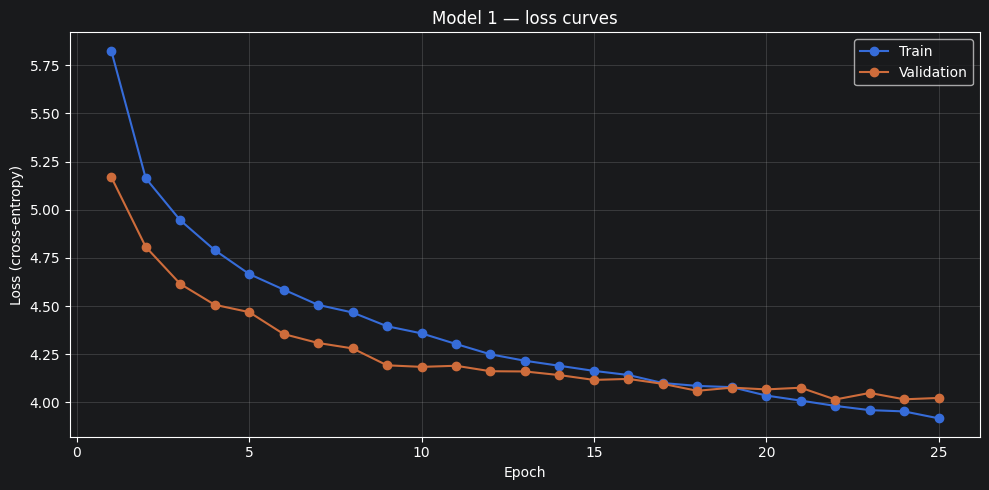

In [10]:
if Path(CSV_M1).exists():
    plot_losses_from_csv(CSV_M1, "Model 1 — loss curves")
elif 'history_m1' in dir() and history_m1:
    plot_loss_curves(history_m1, "Model 1 — loss curves")
else:
    print("No Model 1 loss data yet — run training cell 6.1 first.")



### 6.3 Model 1 — BLEU evaluation


In [11]:
load_best_weights(model1, CKPT_M1)

print("\n--- Model 1 BLEU (beam search) ---")
print(f"Evaluating up to {MAX_BLEU_IMAGES} images per split (set MAX_BLEU_IMAGES=None for full set)")
bleu_m1_val = evaluate_bleu(model1, val_loader, "val", beam_width=BEAM_WIDTH, tag="M1")
bleu_m1_test = evaluate_bleu(model1, test_loader, "test", beam_width=BEAM_WIDTH, tag="M1")

if RUN_GREEDY_BLEU:
    print("\n--- Model 1 BLEU (greedy, comparison) ---")
    bleu_m1_val_greedy = evaluate_bleu(model1, val_loader, "val", beam_width=1, tag="M1 greedy")
    bleu_m1_test_greedy = evaluate_bleu(model1, test_loader, "test", beam_width=1, tag="M1 greedy")
else:
    bleu_m1_val_greedy = bleu_m1_test_greedy = None
    print("Skipping greedy BLEU (RUN_GREEDY_BLEU=False)")

with open(RESULTS_DIR / "model1_bleu.json", "w") as f:
    json.dump({
        "max_images": MAX_BLEU_IMAGES,
        "val_beam": bleu_m1_val, "test_beam": bleu_m1_test,
        "val_greedy": bleu_m1_val_greedy, "test_greedy": bleu_m1_test_greedy,
    }, f, indent=2)
print("Saved", RESULTS_DIR / "model1_bleu.json")



Loaded best weights: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model1_best.pt

--- Model 1 BLEU (beam search) ---
Evaluating up to None images per split (set MAX_BLEU_IMAGES=None for full set)

>>> BLEU M1 val [beam=5] (full split) — ~30-90 sec/image on M1


BLEU M1 val:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1162 images for val BLEU
  val BLEU-1: 0.5974
  val BLEU-2: 0.4137
  val BLEU-3: 0.2876
  val BLEU-4: 0.2029

>>> BLEU M1 test [beam=5] (full split) — ~30-90 sec/image on M1


BLEU M1 test:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1163 images for test BLEU
  test BLEU-1: 0.5924
  test BLEU-2: 0.4019
  test BLEU-3: 0.2719
  test BLEU-4: 0.1893
Skipping greedy BLEU (RUN_GREEDY_BLEU=False)
Saved /Users/rohanchaudhary/projects/DL_AT3/results/model1_bleu.json


### 6.4 Model 1 — BLEU bar chart


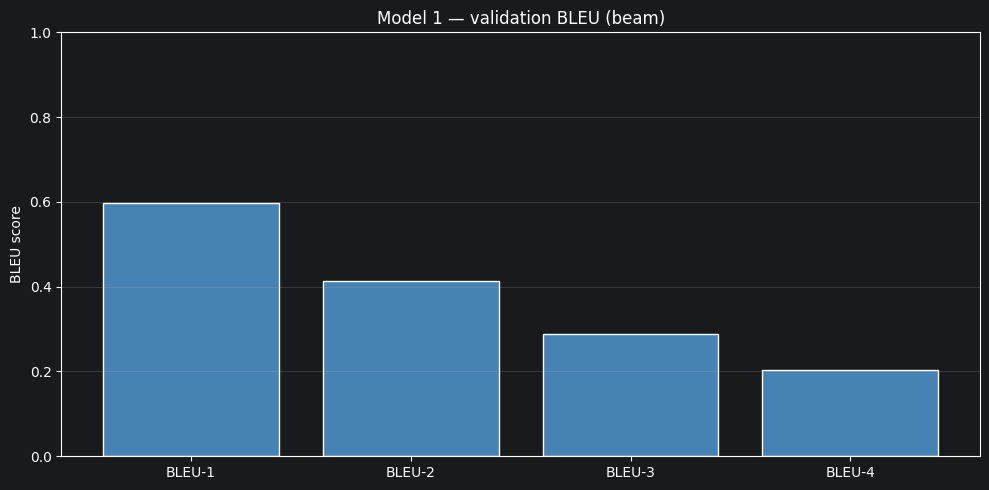

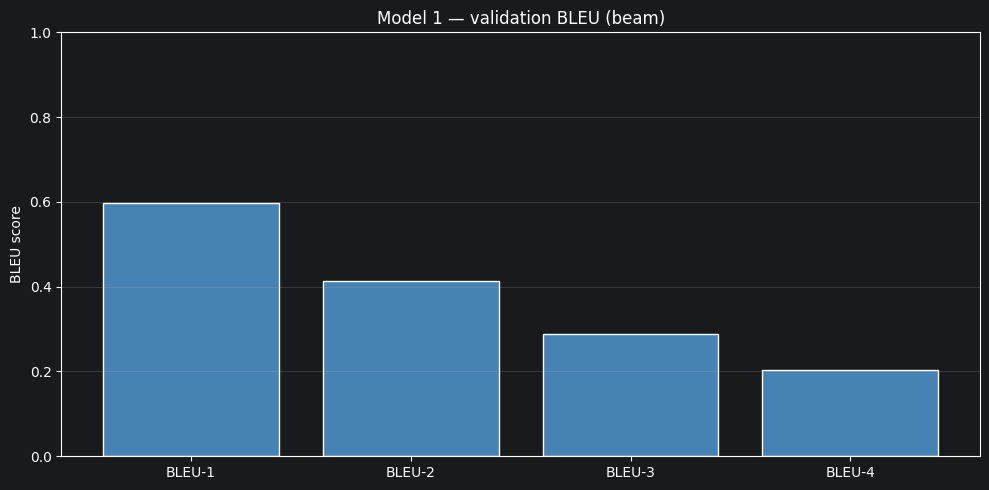

In [13]:
plot_bleu_scores(bleu_m1_val, "Model 1 — validation BLEU (beam)")


### 6.5 Model 1 — qualitative samples


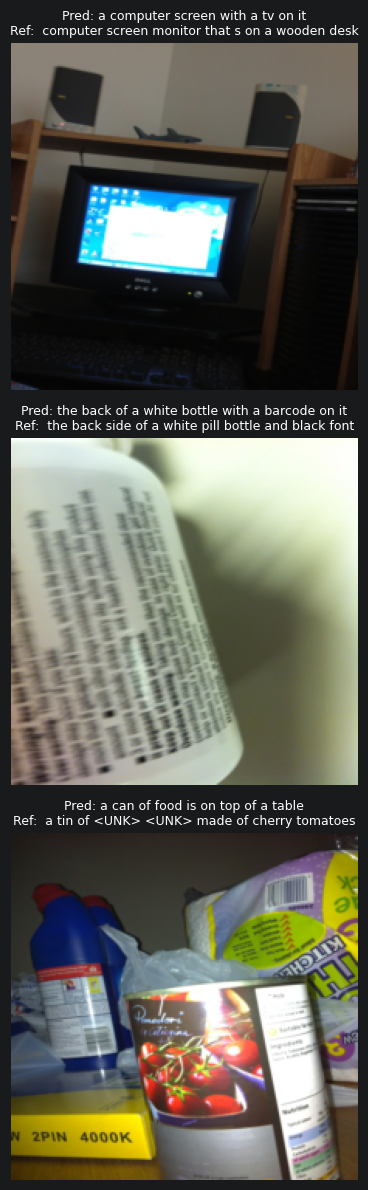

In [14]:
show_prediction_samples(model1, val_loader, vocab, n=3)



### Group discussion → Model 2 design (Phase 2 → 3)

After comparing Phase 2 runs, the group noted:
- Global-pool encoders + plain RNNs under-describe local objects in blurry VizWiz photos.
- **Spatial attention** and **deeper pretrained encoders** (ResNet-50) improve captions.
- **Dropout** and **beam search at inference** improve BLEU without changing training loss.

**My response:** keep a **different** lightweight baseline (VGG+GRU) for Model 1; upgrade Model 2 to **ResNet-50 + attention LSTM** with feature dropout, matching the tutorial recipe that reached ~0.25+ BLEU-4 in peer runs.


## 8. Phase 3 — Model 2: ResNet-50 spatial + attention LSTM


In [ ]:
# Model 2 — Show-Attend-and-Tell style (target: clear BLEU gain over Model 1)
EPOCHS_M2 = 1 if QUICK_TEST else 35
LR_DEC_M2 = 4e-4
LR_ENC_M2 = 1e-4
FREEZE_M2 = 0  
DROPOUT_M2 = 0.5
FEATURE_DROPOUT_M2 = 0.1
CSV_M2 = RESULTS_DIR / "model2_losses.csv"
CKPT_M2 = CHECKPOINTS_DIR / "model2_best.pt"

model2 = CaptionModelPhase3(
    len(vocab), pad_idx=PAD_IDX,
    dropout=DROPOUT_M2, feature_dropout=FEATURE_DROPOUT_M2,
    embed_dim=512, hidden_dim=512, attention_dim=512,
).to(DEVICE)
print(model2.ARCH_NAME)
print(f"Parameters: {sum(p.numel() for p in model2.parameters())/1e6:.2f}M")
print(f"Train: {EPOCHS_M2} ep | dec LR {LR_DEC_M2} | enc LR {LR_ENC_M2} | freeze enc {FREEZE_M2} ep")


ResNet-50 spatial + attention LSTM + feature dropout
Parameters: 36.57M
Train: 35 ep | dec LR 0.0004 | enc LR 0.0001 | freeze enc 0 ep


### 8.1 Train Model 2


In [16]:
if SKIP_TRAIN_IF_CKPT and CKPT_M2.exists():
    print(f"SKIP Model 2 training — using existing {CKPT_M2.name}")
    load_best_weights(model2, CKPT_M2)
    ckpt_m2 = CKPT_M2
    history_m2 = pd.read_csv(CSV_M2).to_dict("records") if CSV_M2.exists() else []
else:
    history_m2, ckpt_m2 = train_model(
        model2, train_loader_m2, val_loss_loader_m2,
        epochs=EPOCHS_M2, lr=LR_DEC_M2, csv_path=CSV_M2, model_label="Model 2",
        checkpoint_path=CKPT_M2, freeze_encoder_epochs=FREEZE_M2,
        encoder_lr=LR_ENC_M2,
        early_stop_patience=6,
        use_attention=True,
    )
    load_best_weights(model2, ckpt_m2)

test_loss_m2 = evaluate_test_split(model2, test_loss_loader_m2, model_label="Model 2")

torch.save(model2.state_dict(), RESULTS_DIR / "model2_weights.pt")
print("Saved weights:", RESULTS_DIR / "model2_weights.pt")
print("Best checkpoint:", ckpt_m2)


print("\n--- Model 2 caption diversity check (val) ---")
check_prediction_diversity(model2, val_loader, n=30, tag="Model2")







SKIP Model 2 training — using existing model2_best.pt
Loaded best weights: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model2_best.pt

>>> Model 2 — one-time test loss (held-out split)


[Model 2] Epoch 1/1 — test:   0%|          | 0/59 [  0%] 00:00<?

  Final test loss: 4.5569
Saved weights: /Users/rohanchaudhary/projects/DL_AT3/results/model2_weights.pt
Best checkpoint: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model2_best.pt

--- Model 2 caption diversity check (val) ---
  [1] a computer monitor is turned on with a tv screen
  [2] a white piece of paper with black text on it
  [3] a blue and white package of food is on top of a table
  [4] quality issues are too severe to recognize visual content
  [5] a bottle of hand sanitizer sitting on a table
Model2 Unique captions in 30 samples: 27 / 30


### 7.2 Model 2 — loss curves


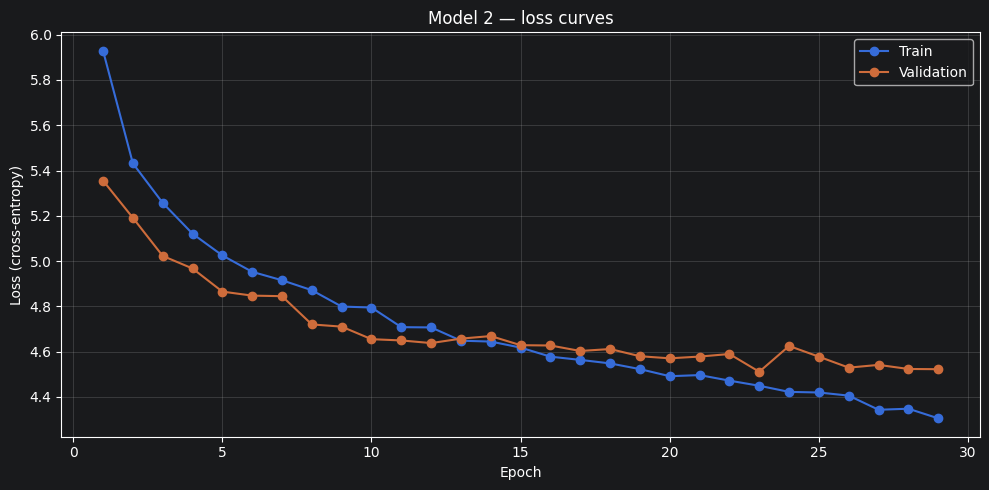

In [17]:
if Path(CSV_M2).exists():
    plot_losses_from_csv(CSV_M2, "Model 2 — loss curves")
elif 'history_m2' in dir() and history_m2:
    plot_loss_curves(history_m2, "Model 2 — loss curves")
else:
    print("No Model 2 loss data yet — run training cell 7.1 first.")



### 7.3 Model 2 — BLEU evaluation


In [18]:
load_best_weights(model2, CKPT_M2)

print("\n--- Model 2 BLEU (beam search) ---")
bleu_m2_val = evaluate_bleu(model2, val_loader, "val", beam_width=BEAM_WIDTH, tag="M2")
bleu_m2_test = evaluate_bleu(model2, test_loader, "test", beam_width=BEAM_WIDTH, tag="M2")

if RUN_GREEDY_BLEU:
    print("\n--- Model 2 BLEU (greedy) ---")
    bleu_m2_val_greedy = evaluate_bleu(model2, val_loader, "val", beam_width=1, tag="M2 greedy")
    bleu_m2_test_greedy = evaluate_bleu(model2, test_loader, "test", beam_width=1, tag="M2 greedy")
else:
    bleu_m2_val_greedy = bleu_m2_test_greedy = None

with open(RESULTS_DIR / "model2_bleu.json", "w") as f:
    json.dump({
        "max_images": MAX_BLEU_IMAGES,
        "val_beam": bleu_m2_val, "test_beam": bleu_m2_test,
        "val_greedy": bleu_m2_val_greedy, "test_greedy": bleu_m2_test_greedy,
    }, f, indent=2)
print("Saved", RESULTS_DIR / "model2_bleu.json")



Loaded best weights: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model2_best.pt

--- Model 2 BLEU (beam search) ---

>>> BLEU M2 val [beam=5] (full split) — ~30-90 sec/image on M1


BLEU M2 val:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1162 images for val BLEU
  val BLEU-1: 0.6044
  val BLEU-2: 0.4229
  val BLEU-3: 0.2957
  val BLEU-4: 0.2107

>>> BLEU M2 test [beam=5] (full split) — ~30-90 sec/image on M1


BLEU M2 test:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1163 images for test BLEU
  test BLEU-1: 0.5991
  test BLEU-2: 0.4178
  test BLEU-3: 0.2886
  test BLEU-4: 0.2051
Saved /Users/rohanchaudhary/projects/DL_AT3/results/model2_bleu.json


### 7.4 Model 2 — BLEU bar chart


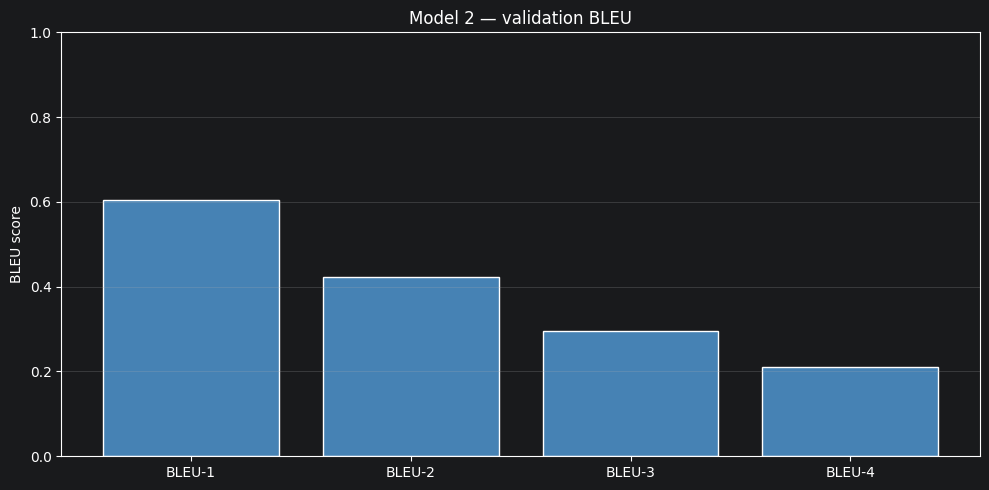

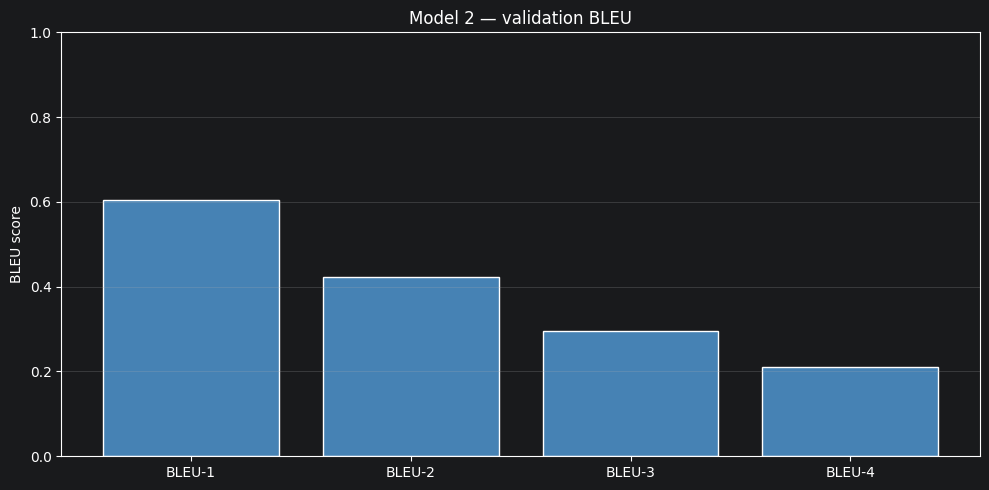

In [19]:
plot_bleu_scores(bleu_m2_val, "Model 2 — validation BLEU")



### 7.5 Model 2 — qualitative samples


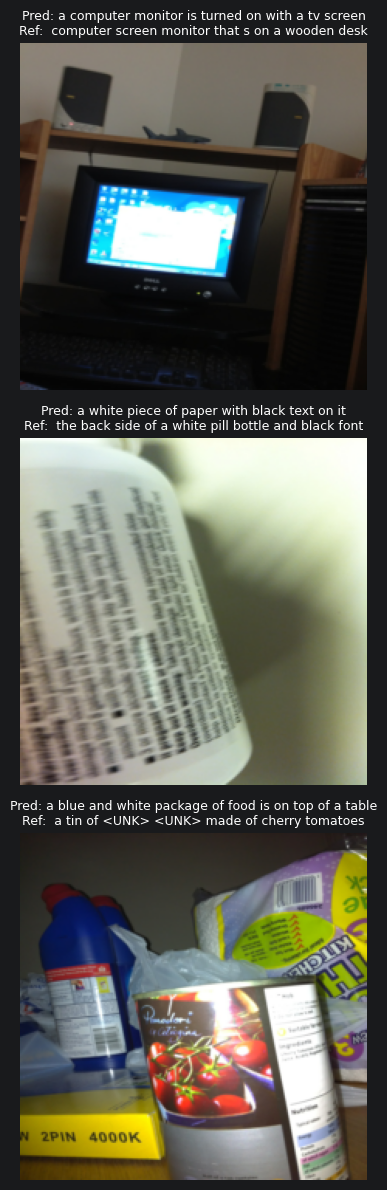

In [20]:
show_prediction_samples(model2, val_loader, vocab, n=3)



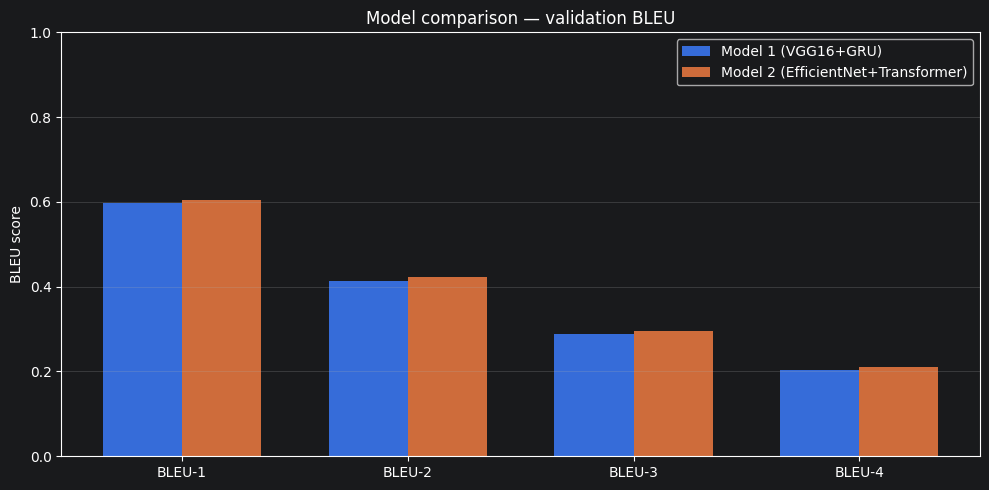

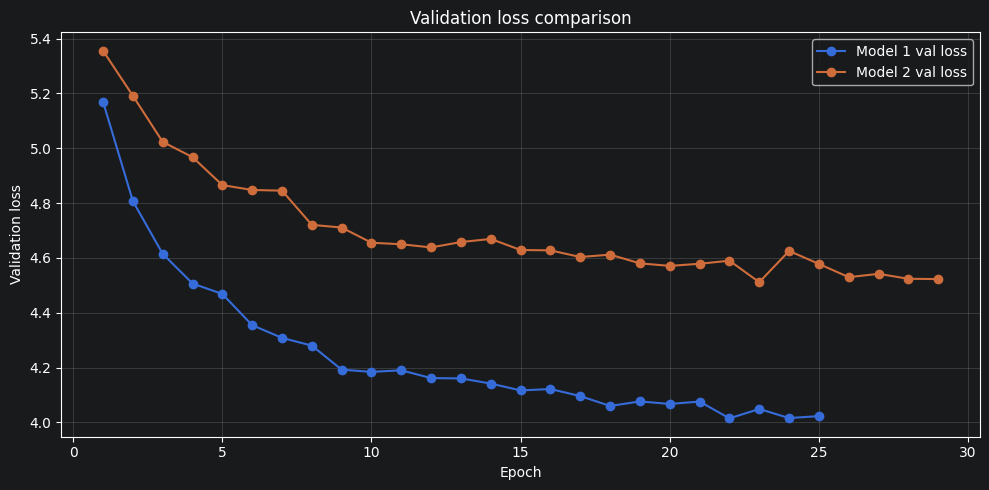

In [21]:
# Use in-memory BLEU or reload after kernel restart
if 'bleu_m1_val' not in dir():
    p = RESULTS_DIR / 'model1_bleu.json'
    if p.exists():
        bleu_m1_val = json.load(open(p))['val_beam']
if 'bleu_m2_val' not in dir():
    p = RESULTS_DIR / 'model2_bleu.json'
    if p.exists():
        bleu_m2_val = json.load(open(p))['val_beam']

if 'bleu_m1_val' in dir() and 'bleu_m2_val' in dir():
    plot_model_comparison(bleu_m1_val, bleu_m2_val)
if Path(CSV_M1).exists() and Path(CSV_M2).exists():
    plot_val_loss_comparison(CSV_M1, CSV_M2)
else:
    print('Run BLEU + training for both models to fill comparison plots.')



### Summary table (fill after running)


In [22]:
comparison_df = pd.DataFrame({
    "Metric": ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"],
    "Model 1 val (beam)": [bleu_m1_val.get(f"BLEU-{i}", 0) for i in range(1, 5)],
    "Model 1 test (beam)": [bleu_m1_test.get(f"BLEU-{i}", 0) for i in range(1, 5)],
    "Model 2 val (beam)": [bleu_m2_val.get(f"BLEU-{i}", 0) for i in range(1, 5)],
    "Model 2 test (beam)": [bleu_m2_test.get(f"BLEU-{i}", 0) for i in range(1, 5)],
})
print(comparison_df.round(4).to_string(index=False))



Metric  Model 1 val (beam)  Model 1 test (beam)  Model 2 val (beam)  Model 2 test (beam)
BLEU-1              0.5974               0.5924              0.6044               0.5991
BLEU-2              0.4137               0.4019              0.4229               0.4178
BLEU-3              0.2876               0.2719              0.2957               0.2886
BLEU-4              0.2029               0.1893              0.2107               0.2051
